In [15]:
import gseapy as gp
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

## Analyze DEGs from single-cell data
First: Load in your adata object (edit path as needed).

In [3]:
adata = sc.read_h5ad(
    "/Users/norawolcott/Documents/Datta Lab/data/scRNA-seq/260812/results/adata_mature_osn.h5ad"
)

output_dir = "/Users/norawolcott/Documents/Datta Lab/data/scRNA-seq/260812/results/DE analysis"

/opt/miniconda3/lib/python3.13/site-packages/anndata/_core/anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Get differential expression between groups

In [4]:
sc.tl.rank_genes_groups(
    adata,
    groupby="condition",
    groups=["GD18-preg"],
    reference="GD18-control",
    method="wilcoxon"
)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Extract DE results for specific group

In [5]:
deg_results = sc.get.rank_genes_groups_df(
    adata,
    group="GD18-preg"
)

Create a ranked gene list

In [6]:
ranked_genes = (
    deg_results
    .set_index("names")["scores"]
    .dropna()
)

Run GSEApy prerank enrichment analysis

In [7]:
enr = gp.prerank(
    rnk=ranked_genes,
    gene_sets=[
        'GO_Biological_Process_2025',
        'WikiPathways_2024_Mouse',
        'MSigDB_Hallmark_2020'
    ],
    organism='mouse',
    permutation_num=1000,
    outdir=None
)

print(enr.res2d.head())

2026-08-20 16:24:05,706 [WARNING] Duplicated values found in preranked stats: 66.63% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


      Name                                               Term        ES  \
0  prerank  GO_Biological_Process_2025__Regulation of Endo... -0.908189   
1  prerank      WikiPathways_2024_Mouse__GPCRs Odorant WP1397  0.812133   
2  prerank  GO_Biological_Process_2025__Aortic Valve Devel... -0.860648   
3  prerank  GO_Biological_Process_2025__Negative Regulatio... -0.931368   
4  prerank  GO_Biological_Process_2025__Sodium Ion Transpo...  -0.76722   

        NES NOM p-val FDR q-val FWER p-val   Tag %  Gene %  \
0 -1.514331  0.005013       1.0      0.872    8/45   4.51%   
1  1.466084  0.004608  0.997083      0.604  20/137  12.17%   
2 -1.427869  0.022472       1.0        1.0    8/40   3.78%   
3 -1.411905  0.013812       1.0        1.0    4/26   3.91%   
4 -1.409269  0.022792       1.0        1.0   20/93   5.29%   

                                          Lead_genes  
0     Nfe2l2;Xbp1;Krit1;Pdcd4;Pdpk1;Ano6;Mapk7;Prkci  
1  Gpr137;Gpr162;Gpr158;Gpr137c;Gpr137b;Gpr108;Gp...  
2       Rbp

Plot

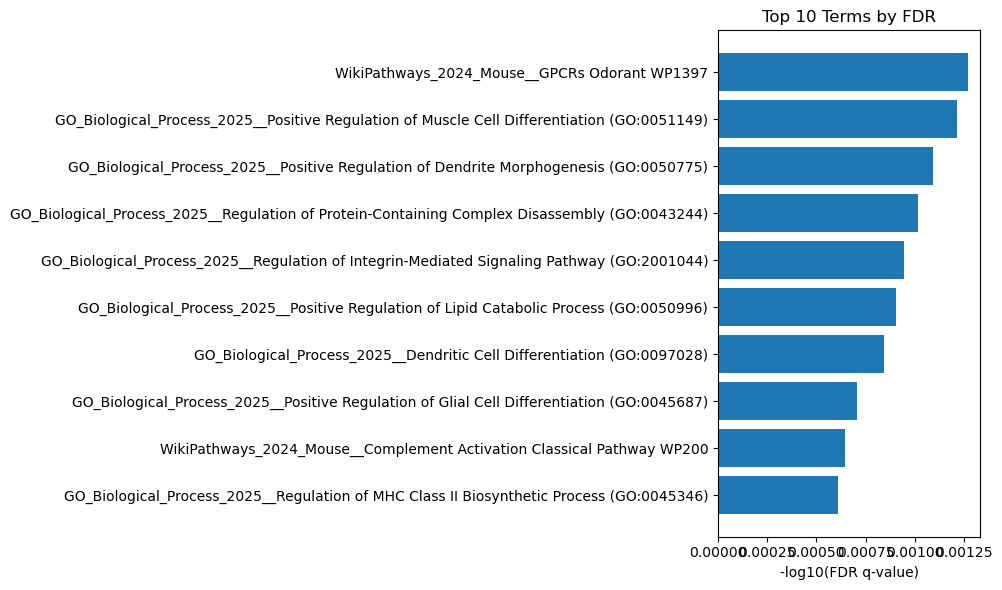

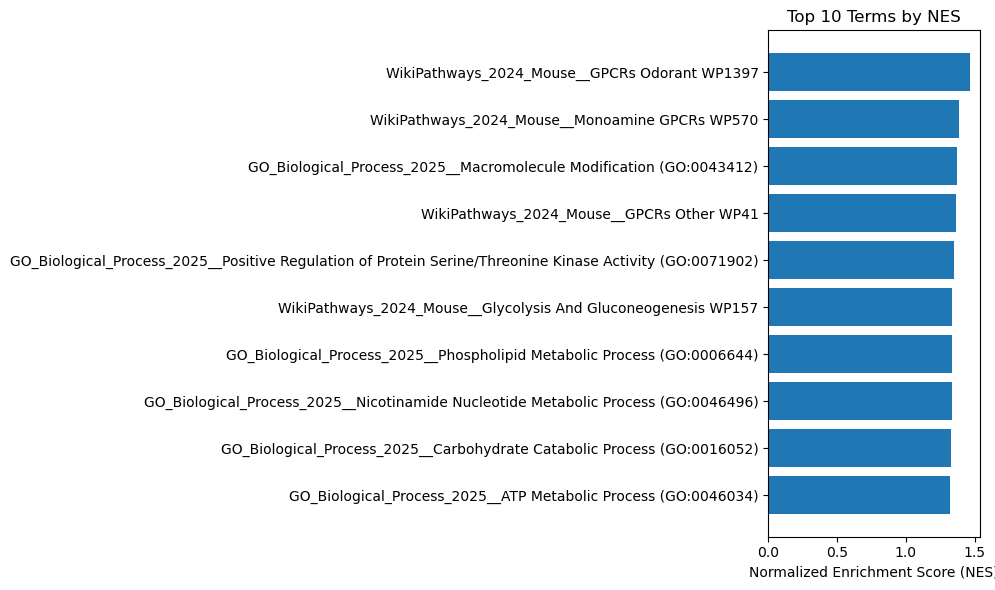

In [17]:
# Make sure numeric columns are actually numeric
results["FDR q-val"] = pd.to_numeric(results["FDR q-val"], errors="coerce")
results["NES"] = pd.to_numeric(results["NES"], errors="coerce")

# Keep only terms with valid FDR values
plot_results = results.dropna(subset=["FDR q-val", "NES"])

# 1. Top 10 terms by FDR q-value
top_fdr = plot_results.sort_values("FDR q-val").head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_fdr["Term"],
    -np.log10(top_fdr["FDR q-val"])
)
plt.xlabel("-log10(FDR q-value)")
plt.title("Top 10 Terms by FDR")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 2. Top 10 terms by NES
top_nes = plot_results.sort_values("NES", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_nes["Term"],
    top_nes["NES"]
)
plt.xlabel("Normalized Enrichment Score (NES)")
plt.title("Top 10 Terms by NES")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

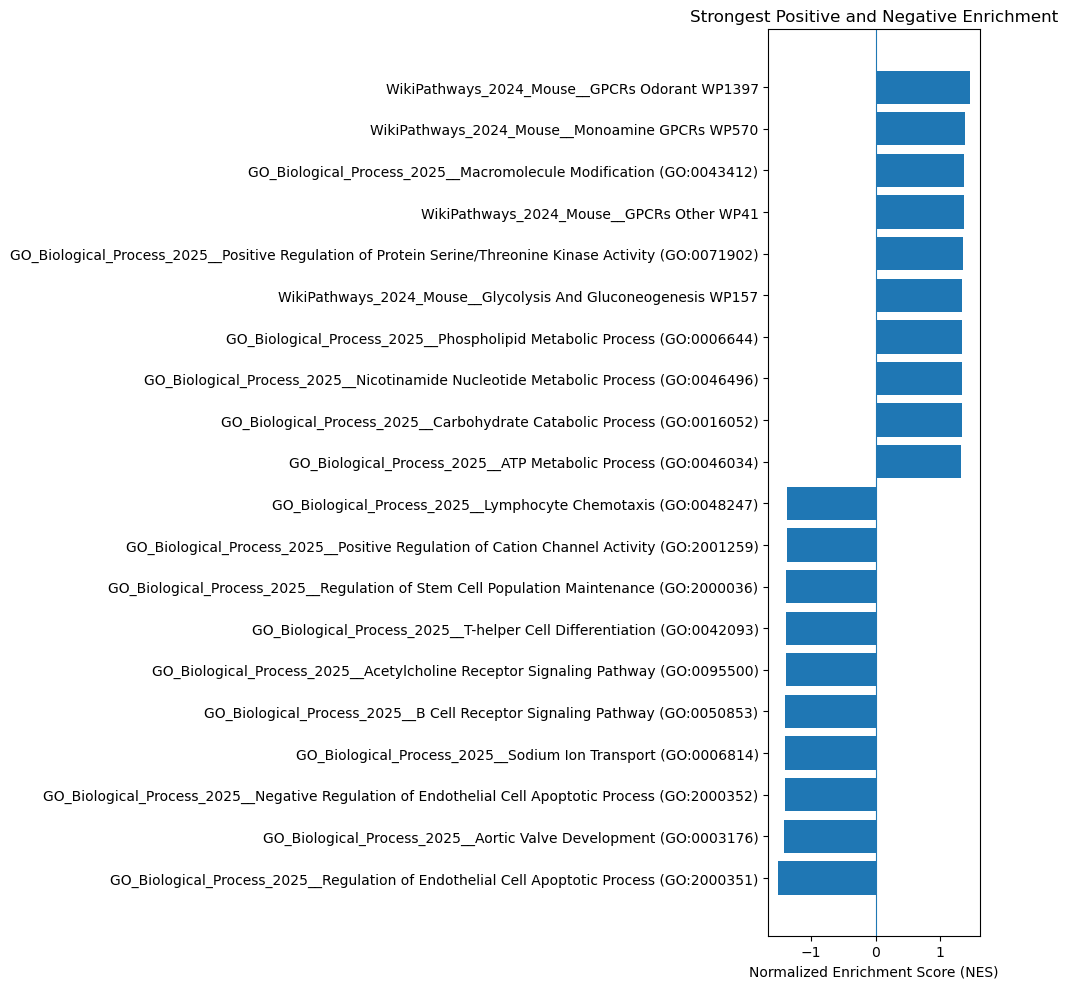

In [18]:
# 10 strongest positive NES
top_positive = plot_results.nlargest(10, "NES")

# 10 strongest negative NES
top_negative = plot_results.nsmallest(10, "NES")

# Combine
top_nes = pd.concat([top_negative, top_positive])

# Sort for plotting
top_nes = top_nes.sort_values("NES")

plt.figure(figsize=(10, 10))
plt.barh(top_nes["Term"], top_nes["NES"])
plt.axvline(0, linewidth=0.8)
plt.xlabel("Normalized Enrichment Score (NES)")
plt.title("Strongest Positive and Negative Enrichment")
plt.tight_layout()
plt.show()

Identify specifically enriched genes

In [24]:
# Copy results
res = enr.res2d.copy()

# Make sure FDR is numeric
res["FDR q-val"] = pd.to_numeric(res["FDR q-val"], errors="coerce")

# Sort by significance
res = res.sort_values("FDR q-val")

print("\n===== TOP 15 ENRICHED TERMS (p-value) =====")
display(res[["Term", "FDR q-val", "NES"]].head(15))

# Extract genes driving top pathways
print("\n===== GENES DRIVING TOP 15 PATHWAYS (p-value) =====")
for i in range(min(15, len(res))):
    row = res.iloc[i]
    print(f"\n{i+1}. {row['Term']}")
    print("Genes:", row["Lead_genes"])

# Sort by Combined Score (highest first)
res = res.sort_values("Combined Score", ascending=False)

print("\n===== TOP 15 ENRICHED TERMS (combined score) =====")
display(res[["Term", "FDR q-val", "NES"]].head(15))

# Extract genes driving top pathways
print("\n===== GENES DRIVING TOP 15 PATHWAYS (combined score) =====")
for i in range(min(15, len(res))):
    row = res.iloc[i]
    print(f"\n{i+1}. {row['Term']}")
    print("Genes:", row["Lead_genes"])

# Steroid related terms
print("\n===== HORMONE-RELATED TERMS =====")
steroid_terms = res[
    res["Term"].str.contains("ESTROGEN|ESR|PROGESTERONE|ANDROGEN|PROLACTIN|PRL|CORTICOSTEROID|STEROID", case=False, na=False)
]

if len(steroid_terms) > 0:
    display(steroid_terms[["Term", "FDR q-val", "NES"]])
else:
    print("No steroid-related terms found")

# Olfaction related terms
print("\n===== OLFACTION-RELATED TERMS =====")

olfaction_terms = res[
    res["Term"].str.contains(
        "OLFACT|ODOR|OLFACTORY|OSN|RECEPTOR|GPCR",
        case=False,
        na=False
    )
]

if len(olfaction_terms) > 0:
    display(olfaction_terms[["Term", "FDR q-val", "NES"]])
else:
    print("No olfaction-related terms found")

    # Ciliary terms
print("\n===== CILIARY TERMS =====")

ciliary_terms = res[
    res["Term"].str.contains(
        "CILIUM|CILIARY|CILIA",
        case=False,
        na=False
    )
]

if len(ciliary_terms) > 0:
    display(ciliary_terms[["Term", "FDR q-val", "NES"]])
else:
    print("No ciliary terms found")

if len(ciliary_terms) > 0:
    display(ciliary_terms[["Term", "FDR q-val", "NES"]])

    # Extract genes driving top 15 ciliary pathways (by combined score)
    print("\n===== GENES DRIVING TOP CILIARY TERMS (combined score) =====")
    
    top_ciliary = ciliary_terms.sort_values(
        "NES", ascending=False
    ).head(15)

    for i, (_, row) in enumerate(top_ciliary.iterrows(), start=1):
        print(f"\n{i}. {row['Term']}")
        print("Genes:", row["Lead_genes"])

else:
    print("No ciliary terms found")


===== TOP 15 ENRICHED TERMS (p-value) =====


,Term,FDR q-val,NES
1,WikiPathways_2024_Mouse__GPCRs Odorant WP1397,0.997083,1.466084
2706,GO_Biological_Process_2025__Positive Regulatio...,0.997207,0.556709
2704,GO_Biological_Process_2025__Positive Regulatio...,0.997481,0.55969
2703,GO_Biological_Process_2025__Regulation of Prot...,0.997660,0.563249
2707,GO_Biological_Process_2025__Regulation of Inte...,0.997828,0.542907
2702,GO_Biological_Process_2025__Positive Regulatio...,0.997924,0.565899
2696,GO_Biological_Process_2025__Dendritic Cell Dif...,0.998060,-0.578505
2701,GO_Biological_Process_2025__Positive Regulatio...,0.998370,0.567147
2698,WikiPathways_2024_Mouse__Complement Activation...,0.998512,0.576939
2693,GO_Biological_Process_2025__Regulation of MHC ...,0.998596,-0.581422



===== GENES DRIVING TOP 15 PATHWAYS (p-value) =====

1. WikiPathways_2024_Mouse__GPCRs Odorant WP1397
Genes: Gpr137;Gpr162;Gpr158;Gpr137c;Gpr137b;Gpr108;Gpr37;Gpr63;Gpr135;Lgr4;Gpr89;Gpr27;Tpra1;Gpr152;Adgra3;Gpr155;Gpr146;Gpr160;Gpr180;Gpr173

2. GO_Biological_Process_2025__Positive Regulation of Muscle Cell Differentiation (GO:0051149)
Genes: Lamc1;Notch4;Mapk11;Lmnb2

3. GO_Biological_Process_2025__Positive Regulation of Dendrite Morphogenesis (GO:0050775)
Genes: Dhx36;Fbxw8;Cdkl3;Dbn1

4. GO_Biological_Process_2025__Regulation of Protein-Containing Complex Disassembly (GO:0043244)
Genes: Atg5;Cln3;Tecpr1;Etf1;Insr;Gspt1

5. GO_Biological_Process_2025__Regulation of Integrin-Mediated Signaling Pathway (GO:2001044)
Genes: Itgb1bp1;Lims1;Lamc1;Lims2;Prkd1;Cd63;Lmnb2

6. GO_Biological_Process_2025__Positive Regulation of Lipid Catabolic Process (GO:0050996)
Genes: Mtln;Pnpla2;Irs2;Abcd1;Clstn3;Prkcd

7. GO_Biological_Process_2025__Dendritic Cell Differentiation (GO:0097028)
Genes: F2r

KeyError: 'Combined Score'

In [ ]:
## Optional: plug in specific genes and see if they are up or downreulated in the dataset
genes_of_interest = "TPD52;SRP19;TSC22D1;STK39;GNAI3;UAP1;ACSL3;SAT1;ELL2;LMAN1;SPCS3;CDK6;PMEPA1;DNAJB9;PLPP1;SPDEF"

# Convert to list and standardize
genes_list = [g.strip().upper() for g in genes_of_interest.split(";")]

# Make sure your dataframe symbols are standardized the same way
df_check = df_filtered.copy()
df_check["symbol"] = df_check["symbol"].astype(str).str.strip().str.upper()

# Filter for genes of interest
subset = df_check[df_check["symbol"].isin(genes_list)]

# Sort by fold change
subset = subset.sort_values(["log2FoldChange"])

# Add a direction column
subset["direction"] = subset["log2FoldChange"].apply(
    lambda x: "UP" if x > 0 else "DOWN"
)

# Display relevant columns
display(subset[[
    "symbol",
    "log2FoldChange",
    "padj",
    "direction"
]])

,symbol,log2FoldChange,padj,direction
11218,CDK6,-0.444661,0.044347,DOWN
3258,TSC22D1,-0.381227,0.012591,DOWN
10539,PMEPA1,-0.321270,0.010378,DOWN
14592,SPCS3,0.280222,0.046720,UP
0,GNAI3,0.318223,0.003463,UP
8697,ACSL3,0.325320,0.018692,UP
5610,STK39,0.382149,0.008236,UP
1430,SRP19,0.383019,0.019467,UP
5857,TPD52,0.401756,0.004660,UP
11738,LMAN1,0.426796,0.032155,UP


## Compare different groups

In [ ]:
# Load in all timepoints for hormone of interest
timepoints = ["45min", "3hr", "6hr", "24hr"]

dfs = []

for tp in timepoints:
    df = pd.read_csv(
        f'/Users/norawolcott/Documents/Datta Lab/data/Biopolymer Facility Seq/260403/Contrast tables/'
        f'DESeq2_{hormone_of_interest}_F_{tp}_vs_vehicle_F_{tp}.csv'
    )
    df["timepoint"] = tp
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

# Remove duplicates
combined_df_clean = (
    combined_df.sort_values("padj")  # prioritize most significant
      .dropna(subset=["padj"])  # remove NaNs
)

# Filter low confidence and uninformative genes
combined_df_filtered = combined_df_clean[combined_df_clean["baseMean"] > 10]
combined_df_filtered = combined_df_filtered[combined_df_filtered["padj"].notna()]
combined_df_filtered = combined_df_filtered[~combined_df_filtered["symbol"].str.contains("Rnr|Rpl|Rps|Cct|Gm|Exo|ENSMUSG", na=False)]

combined_df_clean[
    combined_df_clean["symbol"].str.contains("Obp1a", na=False)
]

,Unnamed: 0,baseMean,log2FoldChange,lfcSE,pvalue,padj,symbol,timepoint
94988,ENSMUSG00000067684,550883.296757,5.595439,1.337210,1.666673e-07,0.000159,Obp1a,6hr
16664,ENSMUSG00000067684,550883.296757,0.049439,0.187298,3.963952e-02,0.141717,Obp1a,45min
55826,ENSMUSG00000067684,550883.296757,0.004215,0.049458,4.670795e-03,0.245029,Obp1a,3hr
134150,ENSMUSG00000067684,550883.296757,0.038051,0.233394,1.536743e-01,0.352126,Obp1a,24hr


Perform enrichment analysis across all groups

In [ ]:
enrichments = {}

for tp in timepoints:
    subset = combined_df_filtered[
        (combined_df_filtered["timepoint"] == tp) &
        (combined_df_filtered["padj"] < 0.08)
    ]
    
    gene_list = subset["symbol"].dropna().unique().tolist()

    enr = gp.enrichr(
        gene_list=gene_list,
        gene_sets=[
            'GO_Biological_Process_2025',
          'WikiPathways_2024_Mouse',
           'MSigDB_Hallmark_2020' # technically human but used in mouse estrogen studies
       ],
       organism='mouse',
      outdir='enrichr_results'
    )
    
    enrichments[tp] = enr.results

Find which DEGs are shared across timepoints

In [ ]:
# Get DEG sets per timepoint
deg_sets = {}

for tp in timepoints:
    subset = combined_df_filtered[
        (combined_df_filtered["timepoint"] == tp) &
        (combined_df_filtered["padj"] < 0.08)
    ]
    
    deg_sets[tp] = set(
        subset["symbol"]
        .dropna()
        .str.upper()
    )

print(deg_sets.keys())

for tp, genes in deg_sets.items():
    print(tp, len(genes))

    from itertools import combinations

for tp1, tp2 in combinations(timepoints, 2):
    overlap = deg_sets[tp1] & deg_sets[tp2]
    print(f"{tp1} ∩ {tp2}: {len(overlap)} genes")

print(combined_df_filtered[
    (combined_df_filtered["timepoint"] == timepoints[0]) &
    (combined_df_filtered["padj"] < 0.05)
].head())

# See which genes are differentially expressed in all groups
shared_all = reduce(set.intersection, deg_sets.values())
print("Shared across ALL timepoints:", len(shared_all))

# Count how many timepoints each gene appears in
gene_counts = Counter()

for genes in deg_sets.values():
    gene_counts.update(genes)

# Keep genes present in at least 3 timepoints
shared_3plus = {gene for gene, count in gene_counts.items() if count >= 3}

print("Shared across at least 3 timepoints:", len(shared_3plus))

dict_keys(['45min', '3hr', '6hr', '24hr'])
45min 3639
3hr 22
6hr 1709
24hr 3111
45min ∩ 3hr: 9 genes
45min ∩ 6hr: 472 genes
45min ∩ 24hr: 692 genes
3hr ∩ 6hr: 14 genes
3hr ∩ 24hr: 12 genes
6hr ∩ 24hr: 273 genes
               Unnamed: 0     baseMean  log2FoldChange     lfcSE  \
16344  ENSMUSG00000064220  1423.738360       -1.978305  0.276578   
17456  ENSMUSG00000073147  2114.051398       -0.474079  0.078356   
10970  ENSMUSG00000039568  1041.356959        0.486816  0.083128   
3697   ENSMUSG00000022774  2336.838998       -0.421771  0.072046   
2637   ENSMUSG00000020840  2285.564807       -0.380621  0.066003   

             pvalue          padj         symbol timepoint  
16344  3.914294e-14  2.533853e-10         H2ac18     45min  
17456  1.762184e-10  6.844322e-07  5031425E22Rik     45min  
10970  5.527122e-10  1.788945e-06         Ubald1     45min  
3697   6.951458e-10  1.928533e-06          Ncbp2     45min  
2637   1.415123e-09  3.435212e-06           Blmh     45min  
Shared across 

From the genes that are differentially expressed across at least 3 groups, plot which programs they belong to 

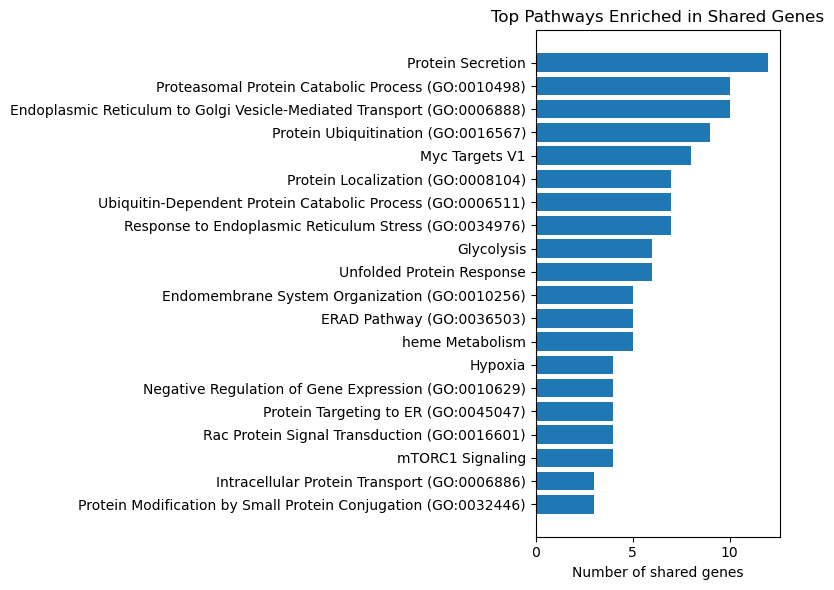

In [ ]:
# Find shared genes in enrichment results
shared_genes = set(shared_3plus)

pathway_hits = []

for tp, df in enrichments.items():   # <- FIXED
    for _, row in df.iterrows():
        pathway_genes = set(row["Genes"].split(";"))

        overlap = shared_genes & pathway_genes

        if len(overlap) > 0:
            pathway_hits.append({
                "timepoint": tp,
                "pathway": row["Term"],
                "pval": row["Adjusted P-value"],
                "overlap_genes": list(overlap),
                "n_overlap": len(overlap)
            })

# Convert to DataFrame
hits_df = pd.DataFrame(pathway_hits)

# Sort by strongest signal
hits_df = hits_df.sort_values(["timepoint", "n_overlap"], ascending=[True, False])

hits_df.head(20)


hits_df = hits_df[hits_df["pval"] < 0.05]

# See which pathways are driven by shared genes across timepoints
hits_df.groupby("pathway")["n_overlap"].sum().sort_values(ascending=False).head(20)

# Plot
# G = nx.Graph()

# for _, row in hits_df.head(50).iterrows():
#     for gene in row["overlap_genes"]:
#         G.add_edge(gene, row["pathway"])

# plt.figure(figsize=(10, 10))
# nx.draw(G, with_labels=False, node_size=10)
# plt.show()

# Count how many shared genes contribute to each pathway
pathway_counts = (
    hits_df.groupby("pathway")["n_overlap"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(pathway_counts.index, pathway_counts.values)
plt.gca().invert_yaxis()
plt.xlabel("Number of shared genes")
plt.title("Top Pathways Enriched in Shared Genes")
plt.tight_layout()
plt.show()